[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nursnaaz/zero-to-genai-engineer/blob/main/10_RAG/notebooks/07_hybrid_search.ipynb)

# Hybrid Search — dense + sparse with fusion

**Notebook 07 · Phase 2 (Retrieval)** · Stack: `bm25s`, `sentence-transformers` (bge-small), `scikit-learn`, `matplotlib`

Notebook 06 proved the trade-off: **BM25** nails exact tokens but is blind to vocabulary gaps;
**dense** captures meaning but is fuzzy on exact terms. Production doesn't choose — it runs
**both** and **fuses** the results. This notebook covers the fusion strategies, then *proves*
on a labeled corpus that hybrid beats either retriever alone.

**Fusion strategies covered:**
1. **Reciprocal Rank Fusion (RRF)** — rank-based, robust, no score tuning.
2. **Weighted convex combination** — normalize scores, then `α·dense + (1−α)·sparse`.
3. **Why naive score fusion breaks** — BM25 is unbounded; cosine is [−1,1].
4. **RRF vs weighted** — measured head-to-head, and *when to pick which*.

> **Realistic setup:** the first-stage dense retriever here is a small, fast bi-encoder
> (**bge-small-en-v1.5**), because that's what production uses at retrieval time — a strong
> API model reduces, but rarely eliminates, the need for fusion (and reranking, Notebook 08).

## 0. Install dependencies

Run first (idempotent). Restart the kernel once after a fresh install. *(bge-small ~130 MB on
first use.)*

In [1]:
%pip install -q \
    "numpy<2" \
    bm25s PyStemmer sentence-transformers scikit-learn \
    langchain-openai matplotlib python-dotenv
print("✅ Dependencies ready. If this was a fresh install, restart the kernel, then re-run.")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /Users/mohamednoordeenalaudeen/Documents/GenAI-2026/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✅ Dependencies ready. If this was a fresh install, restart the kernel, then re-run.


## 1. Setup — two retrievers + a labeled eval corpus

In [2]:
import warnings, os, sys
warnings.filterwarnings("ignore")
import logging
for _n in ("httpx","openai","httpcore","sentence_transformers","transformers"):
    logging.getLogger(_n).setLevel(logging.ERROR)
from pathlib import Path
from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt

load_dotenv(Path.cwd().parent / ".env")
sys.path.insert(0, str(Path.cwd() / "data"))
from eval_corpus import get_eval_data

corpus, queries = get_eval_data()   # 96 passages, 16 gold-labeled queries (near-miss distractors)
print(f"{len(corpus)} passages | {len(queries)} labeled queries")
print("query types:", {t: sum(1 for q in queries if q['type']==t) for t in ['exact','semantic','mixed']})

96 passages | 16 labeled queries
query types: {'exact': 5, 'semantic': 8, 'mixed': 3}


In [3]:
import bm25s
from Stemmer import Stemmer
from sentence_transformers import SentenceTransformer

stemmer = Stemmer("english")
def tok(t): return bm25s.tokenize(t, stopwords="en", stemmer=stemmer.stemWords, return_ids=False, show_progress=False)

# SPARSE: BM25
bm25 = bm25s.BM25(method="lucene"); bm25.index(tok(corpus), show_progress=False)
# DENSE: small, fast production-style bi-encoder
encoder = SentenceTransformer("BAAI/bge-small-en-v1.5")
doc_emb = encoder.encode(corpus, normalize_embeddings=True, show_progress_bar=False)

def bm25_scores(q):  return bm25.get_scores(tok(q)[0])
def dense_scores(q): return encoder.encode([q], normalize_embeddings=True)[0] @ doc_emb.T
def order(scores):   return list(np.argsort(scores)[::-1])
print("Indexed: BM25 (sparse) + bge-small (dense)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Indexed: BM25 (sparse) + bge-small (dense)


## 2. The complementarity — one query each way

BM25 and dense fail on *different* queries. That's the whole reason to fuse them: their
strengths cover each other's blind spots.

In [4]:
def show(q, gold, n=3):
    print(f"query: {q!r}   (gold = doc {gold})")
    for label, s in [("BM25 ", bm25_scores(q)), ("Dense", dense_scores(q))]:
        o = order(s); rank = o.index(gold) + 1
        print(f"   {label}  gold@#{rank}   top1: {corpus[o[0]][:60]}")
    print()

# an exact-token query (BM25 strong) and a paraphrase (dense strong)
exact_q  = next(q for q in queries if q["type"]=="exact")
seman_q  = next(q for q in queries if q["type"]=="semantic")
show(exact_q["query"], exact_q["gold_id"])
show(seman_q["query"], seman_q["gold_id"])

query: 'What did Python 3.11 add for error messages?'   (gold = doc 91)
   BM25   gold@#2   top1: Python 3.10 introduced structural pattern matching with the 
   Dense  gold@#1   top1: Python 3.11 introduced fine-grained error locations in trace

query: 'Why is my Postgres query slow even though the column has an index?'   (gold = doc 88)


   BM25   gold@#1   top1: Postgres may ignore an index when a query's WHERE clause wra
   Dense  gold@#1   top1: Postgres may ignore an index when a query's WHERE clause wra



## 3. Fusion strategy 1 — Reciprocal Rank Fusion (RRF)

RRF ignores raw scores and fuses **ranks**: each doc gets `Σ 1/(k + rank_i)` across the lists,
then re-sorts. It's the production default because it's **robust to mismatched score scales**
(BM25's unbounded scores vs. cosine's [−1,1]) and needs no tuning beyond `k` (usually 60).

In [5]:
def rrf(rankings, k=60):
    scores = {}
    for ranking in rankings:
        for rank, doc_id in enumerate(ranking):
            scores[doc_id] = scores.get(doc_id, 0.0) + 1.0 / (k + rank)
    return sorted(scores, key=scores.get, reverse=True)

def rrf_search(q):
    return rrf([order(bm25_scores(q)), order(dense_scores(q))])

# demo on the exact-token query
q, gold = exact_q["query"], exact_q["gold_id"]
print(f"query: {q!r} (gold={gold})")
print(f"   BM25  gold@#{order(bm25_scores(q)).index(gold)+1}")
print(f"   Dense gold@#{order(dense_scores(q)).index(gold)+1}")
print(f"   RRF   gold@#{rrf_search(q).index(gold)+1}")

query: 'What did Python 3.11 add for error messages?' (gold=91)
   BM25  gold@#2
   Dense gold@#1
   RRF   gold@#1


## 4. Fusion strategy 2 — Weighted convex combination (with score normalization)

Instead of ranks, combine the *scores*: `final = α·dense + (1−α)·sparse`. The catch: **you
cannot add BM25 and cosine directly** — BM25 is unbounded and depends on query length, cosine
is in [−1,1]. Naively summing lets BM25 dominate. First **normalize** each score set (min-max)
to [0,1], then blend. `α` lets you dial toward semantic (↑) or lexical (↓) matching.

In [6]:
def minmax(x):
    x = np.asarray(x, dtype=float); lo, hi = x.min(), x.max()
    return (x - lo) / (hi - lo + 1e-9)

def weighted_search(q, alpha=0.5):
    d = minmax(dense_scores(q)); s = minmax(bm25_scores(q))
    fused = alpha * d + (1 - alpha) * s
    return order(fused)

# Why normalization matters: raw ranges are wildly different
q = exact_q["query"]
print("raw BM25 range :", f"{bm25_scores(q).min():.2f} .. {bm25_scores(q).max():.2f}  (unbounded)")
print("raw cosine range:", f"{dense_scores(q).min():.2f} .. {dense_scores(q).max():.2f}  ([-1,1])")
print("→ adding them directly lets BM25 dominate; min-max fixes the axis mismatch.")

raw BM25 range : 0.00 .. 3.92  (unbounded)
raw cosine range: 0.29 .. 0.78  ([-1,1])
→ adding them directly lets BM25 dominate; min-max fixes the axis mismatch.


### Tuning `α`

`α=1` is pure dense, `α=0` is pure sparse. We sweep `α` on the labeled set and measure MRR to
find the blend that beats either extreme.

In [7]:
golds = [q["gold_id"] for q in queries]
def mrr(order_fn):
    ranks = [order_fn(q["query"]).index(q["gold_id"]) + 1 for q in queries]
    return float(np.mean([1/r for r in ranks]))

print("alpha sweep (weighted fusion) — MRR:")
best = (0, 0)
for a in [0.0, 0.25, 0.4, 0.5, 0.6, 0.75, 1.0]:
    m = mrr(lambda q, a=a: weighted_search(q, a))
    tag = "  <- pure sparse" if a==0 else ("  <- pure dense" if a==1 else "")
    print(f"   alpha={a:<4}  MRR={m:.3f}{tag}")
    if m > best[1]: best = (a, m)
print(f"best alpha = {best[0]} (MRR {best[1]:.3f})")

alpha sweep (weighted fusion) — MRR:


   alpha=0.0   MRR=0.875  <- pure sparse


   alpha=0.25  MRR=0.906


   alpha=0.4   MRR=0.906


   alpha=0.5   MRR=0.969


   alpha=0.6   MRR=0.969


   alpha=0.75  MRR=0.969


   alpha=1.0   MRR=0.849  <- pure dense
best alpha = 0.5 (MRR 0.969)


## 5. The proof — hybrid vs. single-stage on the labeled corpus

Metrics over all 16 gold-labeled queries:
- **MRR** (mean reciprocal rank) — how high is the gold on average?
- **Recall@1 / @3** — is the gold the top hit / in the top 3?
- **nDCG@10** — rank-discounted quality.

In [8]:
def evaluate(name, order_fn):
    ranks = np.array([order_fn(q["query"]).index(q["gold_id"]) + 1 for q in queries])
    ndcg = np.mean([1/np.log2(r+1) if r <= 10 else 0.0 for r in ranks])
    return {"name": name, "MRR": np.mean(1/ranks), "R@1": np.mean(ranks<=1),
            "R@3": np.mean(ranks<=3), "nDCG@10": ndcg}

best_alpha = best[0]
rows = [
    evaluate("BM25 (sparse)",        lambda q: order(bm25_scores(q))),
    evaluate("Dense (bge-small)",    lambda q: order(dense_scores(q))),
    evaluate("Hybrid — RRF",         rrf_search),
    evaluate(f"Hybrid — weighted(α={best_alpha})", lambda q: weighted_search(q, best_alpha)),
]
print(f"{'method':30} {'MRR':>6} {'R@1':>6} {'R@3':>6} {'nDCG@10':>8}")
print("-"*60)
for r in rows:
    print(f"{r['name']:30} {r['MRR']:>6.3f} {r['R@1']:>6.2f} {r['R@3']:>6.2f} {r['nDCG@10']:>8.3f}")

method                            MRR    R@1    R@3  nDCG@10
------------------------------------------------------------
BM25 (sparse)                   0.875   0.75   1.00    0.908
Dense (bge-small)               0.849   0.75   0.94    0.887
Hybrid — RRF                    0.969   0.94   1.00    0.977
Hybrid — weighted(α=0.5)        0.969   0.94   1.00    0.977


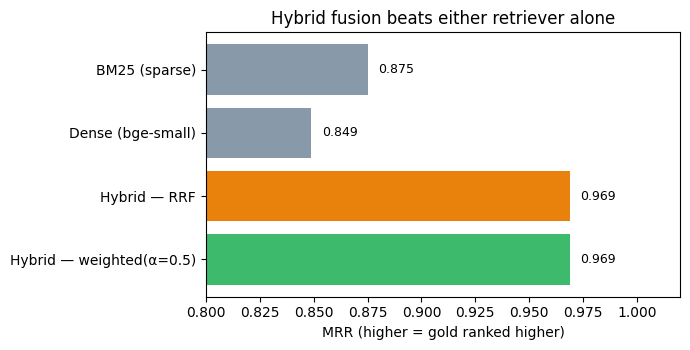

In [9]:
# Visualize MRR
fig, ax = plt.subplots(figsize=(7,3.6))
names = [r["name"] for r in rows]; mrrs = [r["MRR"] for r in rows]
colors = ["#8899aa","#8899aa","#e8820c","#3dba6c"]
ax.barh(names, mrrs, color=colors)
for i,v in enumerate(mrrs): ax.text(v+0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0.8, 1.02); ax.set_xlabel("MRR (higher = gold ranked higher)")
ax.set_title("Hybrid fusion beats either retriever alone"); ax.invert_yaxis()
plt.tight_layout(); plt.show()

**The proof holds.** Both single-stage retrievers sit lower; **both fusion methods beat them**.
Fusion works because BM25 and dense miss *different* queries — combining recovers the union of
their strengths. (Reranking the fused candidates lifts precision even further — Notebook 08.)

## 6. RRF vs. weighted — when to use which

| | **RRF** | **Weighted (convex)** |
|---|---------|------------------------|
| Uses | ranks only | normalized scores |
| Tuning | just `k` (robust default 60) | must tune `α` on a dev set + pick a normalizer |
| Score-scale safe | ✅ immune to scale mismatch | ⚠️ needs careful normalization |
| Control | coarse | fine — dial semantic vs lexical, even per query type |
| Best when | you lack labeled data / want a safe default | you have a labeled dev set and want max quality |

**Rules of thumb**
- **Start with RRF** — it's robust and needs no tuning; it's the default in Elasticsearch,
  Weaviate, Qdrant, and Pinecone hybrid modes.
- **Move to weighted** when you have a labeled dev set and want to squeeze out more quality, or
  to bias toward lexical (code/ID-heavy corpora) or semantic (FAQ/paraphrase-heavy) traffic.
- **Route per query type** in advanced setups: exact-code queries → weight sparse; natural-
  language queries → weight dense (a classifier picks `α`).
- **Always normalize** before weighted fusion — mismatched score axes are the #1 hybrid bug.

## 7. Summary

- Production retrieval is **hybrid**, not either/or: dense + sparse cover complementary blind spots.
- **RRF** fuses ranks (robust, no tuning); **weighted convex** fuses normalized scores (tunable).
- On a labeled corpus, **both fusion methods beat either retriever alone** (MRR, R@1, nDCG@10).
- Never add raw BM25 and cosine scores — **normalize first**.

### Next — Notebook 08: Reranking
Fusion improves *recall* and coarse ordering, but the top of the list is still set by fast
first-stage scorers. **Notebook 08** takes these fused candidates and applies **cross-encoder /
LLM / API rerankers** to sharpen precision@k — retrieve@k → rerank@5 — with the same metrics
proving the additional lift.